# DOT Yearly Budget Forecast (FY2027-FY2028)

A simple, honest trend forecast for DOT's Adopted, Modified, and Actual
budget totals, built on the corrected year-by-year table from
`dot_analysis.ipynb` (DOT-filtered, expense-scope-aligned). **This notebook
is rebuilt directly from the raw CSVs using the same two corrections
documented there**, rather than importing that notebook, so it stays
self-contained and reproducible on its own.

**Headline limitation, stated up front and repeated throughout:** this is
~10 annual observations. That supports a simple linear trend with an
honest uncertainty band -- not a complex model. Every forecast below ships
with an interval, never a bare point estimate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = "raw datasets"
BUDGET_PATH = f"{DATA_DIR}/DOT_Budget_2017_2027.csv"
SPENDING_PATH = f"{DATA_DIR}/DOT_Spending_Merged.csv"


## Step 1: Load

Rebuild the corrected year-level table: DOT-only budget (`Agency ==
"Department of Transportation"`, fixes the FY2022 multi-agency
contamination) joined with expense-scope-only spending (Budget Code must
exist in the DOT operating budget, fixes the capital-vs-expense scope
mismatch) -- the same two corrections from `dot_analysis.ipynb`, applied
here from scratch.

**FY2027 is excluded from the training set** -- it's a partial fiscal year
(barely a month elapsed as of this analysis), so its `actual` figure is
nowhere near comparable to a full-year total, and including it would teach
the trend a false year-over-year drop. It's kept aside, unused in fitting,
for the Step 5 sanity check.

In [2]:
# --- Budget: DOT-only ---
budget_raw = pd.read_csv(BUDGET_PATH)
budget = budget_raw[budget_raw["Agency"] == "Department of Transportation"].copy()
print(f"Budget: {len(budget_raw):,} raw rows -> {len(budget):,} DOT-only rows")

# --- Spending: expense-scope only ---
spending_raw = pd.read_csv(SPENDING_PATH)
dot_budget_codes = set(budget["Budget Code"].astype(str).str.strip())
spending_code_lead = spending_raw["Budget Code"].astype(str).str.extract(r"^([^\s(]+)")[0]
is_expense = spending_code_lead.isin(dot_budget_codes)
spending = spending_raw[is_expense].copy()
print(f"Spending: {len(spending_raw):,} raw rows -> {len(spending):,} expense-scope rows")

# --- Aggregate to fiscal year, FY2017-2027 ---
budget_by_year = (
    budget[budget["Year"].between(2017, 2027)]
    .groupby("Year")[["Adopted", "Modified"]]
    .sum()
    .rename(columns={"Adopted": "adopted", "Modified": "modified"})
)
spending_by_year = (
    spending[spending["Fiscal year"].between(2017, 2027)]
    .groupby("Fiscal year")["Check Amount"]
    .sum()
    .rename("actual")
)

full_table = (
    budget_by_year.join(spending_by_year, how="outer")
    .rename_axis("fiscal_year")
    .reset_index()
    .sort_values("fiscal_year")
    .reset_index(drop=True)
)
print("\nFull corrected table, FY2017-2027:")
full_table


Budget: 334,806 raw rows -> 172,576 DOT-only rows


Spending: 1,178,715 raw rows -> 1,049,180 expense-scope rows

Full corrected table, FY2017-2027:


,fiscal_year,adopted,modified,actual
0,2017,"946,261,935.00","987,004,764.00","901,930,214.87"
1,2018,"968,043,444.00","1,006,587,224.00","937,183,870.64"
2,2019,"1,042,719,292.00","1,067,012,833.00","953,000,693.10"
3,2020,"1,104,236,297.00","1,117,601,805.00","997,409,678.73"
4,2021,"1,099,873,821.00","1,155,962,285.00","962,343,265.13"
5,2022,"1,265,808,124.00","1,294,564,083.00","1,105,430,478.04"
6,2023,"1,438,489,469.00","1,448,998,543.00","1,222,150,442.62"
7,2024,"1,405,341,510.00","1,476,734,619.00","1,353,530,012.62"
8,2025,"1,449,323,202.00","1,568,194,105.00","1,423,722,022.97"
9,2026,"1,503,042,033.00","1,599,799,084.00","1,437,635,892.24"


In [3]:
# Split off FY2027 -- kept aside for the Step 5 sanity check, not used in fitting.
train_table = full_table[full_table["fiscal_year"] <= 2026].reset_index(drop=True)
fy2027_actual_row = full_table[full_table["fiscal_year"] == 2027].iloc[0]

print(f"Training table: FY2017-2026 ({len(train_table)} observations)")
print("FY2027 (excluded from training, held out for sanity check in Step 5):")
print(fy2027_actual_row)
print()
train_table


Training table: FY2017-2026 (10 observations)
FY2027 (excluded from training, held out for sanity check in Step 5):
fiscal_year           2,027.00
adopted       1,636,737,065.00
modified      1,639,747,168.00
actual          161,980,918.70
Name: 10, dtype: float64



,fiscal_year,adopted,modified,actual
0,2017,"946,261,935.00","987,004,764.00","901,930,214.87"
1,2018,"968,043,444.00","1,006,587,224.00","937,183,870.64"
2,2019,"1,042,719,292.00","1,067,012,833.00","953,000,693.10"
3,2020,"1,104,236,297.00","1,117,601,805.00","997,409,678.73"
4,2021,"1,099,873,821.00","1,155,962,285.00","962,343,265.13"
5,2022,"1,265,808,124.00","1,294,564,083.00","1,105,430,478.04"
6,2023,"1,438,489,469.00","1,448,998,543.00","1,222,150,442.62"
7,2024,"1,405,341,510.00","1,476,734,619.00","1,353,530,012.62"
8,2025,"1,449,323,202.00","1,568,194,105.00","1,423,722,022.97"
9,2026,"1,503,042,033.00","1,599,799,084.00","1,437,635,892.24"


## Step 2: Visualize

Adopted, Modified, and Actual over FY2017-2026 on one chart -- the trend
being forecast. Ten annual points per series; markers are shown deliberately
so the sparseness of the underlying data stays visible, not smoothed away.

Saved trend plot to dot_forecast_trend.png


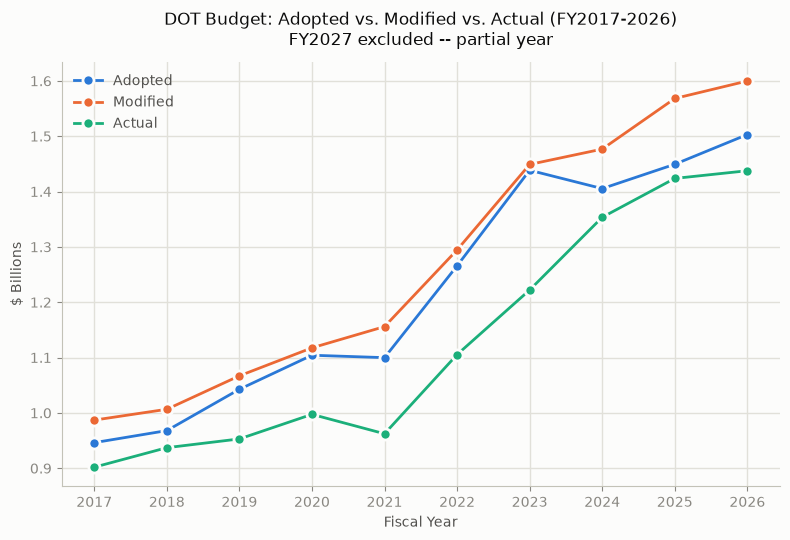

In [4]:
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES = {
    "adopted": "#2a78d6",   # categorical slot 1: blue
    "modified": "#eb6834",  # categorical slot 2: orange
    "actual": "#1baf7a",    # categorical slot 3: aqua
}

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for col, color in SERIES.items():
    ax.plot(
        train_table["fiscal_year"], train_table[col] / 1e9,
        color=color, linewidth=2, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=2,
        label=col.capitalize(),
    )

ax.set_xlabel("Fiscal Year", color=INK_SECONDARY)
ax.set_ylabel("$ Billions", color=INK_SECONDARY)
ax.set_title(
    "DOT Budget: Adopted vs. Modified vs. Actual (FY2017-2026)\n"
    "FY2027 excluded -- partial year",
    color=INK_PRIMARY, fontsize=12, pad=12,
)
ax.set_xticks(train_table["fiscal_year"])

ax.grid(True, color=GRIDLINE, linewidth=1, linestyle="-")
ax.set_axisbelow(True)
for spine_name, spine in ax.spines.items():
    if spine_name in ("top", "right"):
        spine.set_visible(False)
    else:
        spine.set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)

legend = ax.legend(frameon=False, loc="upper left", labelcolor=INK_SECONDARY)

fig.tight_layout()

TREND_PLOT_PATH = "dot_forecast_trend.png"
fig.savefig(TREND_PLOT_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved trend plot to {TREND_PLOT_PATH}")
plt.show()


## Step 3: Forecast

Simple linear regression of each series on Fiscal Year: `y = slope * Year +
intercept`. Slope is annual growth in dollars; R² is how much of the
year-to-year variation a straight line explains. Kept deliberately simple --
with 10 points, a more flexible model would be fitting noise, not signal.

In [5]:
def fit_and_forecast(df, y_col, forecast_years, alpha=0.05):
    """OLS trend fit + classic prediction intervals for new-year forecasts.

    Uses the standard simple-linear-regression prediction interval formula
    (accounts for residual variance AND the extra uncertainty of predicting
    a new point away from the data's center), not just a confidence band on
    the fitted line -- this is deliberately the wider, more honest interval
    for a forecast rather than a fitted-mean estimate.
    """
    x = df["fiscal_year"].values.astype(float)
    y = df[y_col].values.astype(float)
    n = len(x)

    model = LinearRegression().fit(x.reshape(-1, 1), y)
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(x.reshape(-1, 1), y)

    y_pred = model.predict(x.reshape(-1, 1))
    resid = y - y_pred
    dof = n - 2
    resid_se = np.sqrt(np.sum(resid ** 2) / dof)
    xbar = x.mean()
    sxx = np.sum((x - xbar) ** 2)
    t_crit = stats.t.ppf(1 - alpha / 2, df=dof)

    forecast_rows = []
    for x0 in forecast_years:
        yhat0 = slope * x0 + intercept
        se_pred = resid_se * np.sqrt(1 + 1 / n + (x0 - xbar) ** 2 / sxx)
        margin = t_crit * se_pred
        forecast_rows.append({
            "fiscal_year": x0,
            "point_forecast": yhat0,
            "lower_95": yhat0 - margin,
            "upper_95": yhat0 + margin,
            "margin": margin,
        })

    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "n": n,
        "dof": dof,
        "residual_se": resid_se,
        "forecast": pd.DataFrame(forecast_rows),
    }

SERIES_COLS = ["adopted", "modified", "actual"]
FORECAST_YEARS = [2027, 2028]

fits = {col: fit_and_forecast(train_table, col, FORECAST_YEARS) for col in SERIES_COLS}

print("Trend fit summary (FY2017-2026, n=10):")
summary_rows = []
for col in SERIES_COLS:
    f = fits[col]
    summary_rows.append({
        "series": col,
        "slope ($/year)": f["slope"],
        "intercept": f["intercept"],
        "r2": round(f["r2"], 4),
        "residual_se": f["residual_se"],
    })
pd.DataFrame(summary_rows)


Trend fit summary (FY2017-2026, n=10):


,series,slope ($/year),intercept,r2,residual_se
0,adopted,"68,859,297.56","-137,976,756,099.94",0.94,"54,000,313.36"
1,modified,"76,532,109.02","-153,437,412,458.01",0.97,"45,702,818.98"
2,actual,"66,951,965.24","-134,213,964,078.26",0.91,"67,426,110.27"


In [6]:
print("FY2027-2028 point forecasts (95% prediction intervals):\n")
for col in SERIES_COLS:
    print(f"--- {col} ---")
    print(fits[col]["forecast"].to_string(index=False))
    print()


FY2027-2028 point forecasts (95% prediction intervals):

--- adopted ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,601,040,049.27 1,450,232,850.64 1,751,847,247.89 150,807,198.62
        2028 1,669,899,346.82 1,511,790,850.66 1,828,007,842.99 158,108,496.17

--- modified ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,693,172,534.13 1,565,537,828.50 1,820,807,239.77 127,634,705.63
        2028 1,769,704,643.16 1,635,890,531.16 1,903,518,755.15 133,814,112.00

--- actual ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,497,669,465.92 1,309,367,914.09 1,685,971,017.75 188,301,551.83
        2028 1,564,621,431.16 1,367,203,300.88 1,762,039,561.45 197,418,130.29



## Step 4: Uncertainty

The forecasts above are never shown as bare point estimates -- each carries
a 95% prediction interval computed from the fit's own residual variance
(`resid_se`) and the classic new-observation term
`sqrt(1 + 1/n + (x0-xbar)^2/Sxx)`, using a t-distribution with `n-2 = 8`
degrees of freedom (not a normal approximation -- with only 10 points, the
t-distribution's fatter tails matter). The interval widens for FY2028
relative to FY2027 because it's one more year outside the training data's
center -- exactly the "we know less the further out we forecast" behavior a
credible interval should show.

In [7]:
print("Interval width (FY2027 vs FY2028), by series -- should widen further out:")
for col in SERIES_COLS:
    fc = fits[col]["forecast"].set_index("fiscal_year")
    w2027 = fc.loc[2027, "upper_95"] - fc.loc[2027, "lower_95"]
    w2028 = fc.loc[2028, "upper_95"] - fc.loc[2028, "lower_95"]
    print(f"{col:>9}: FY2027 width = {w2027:>15,.0f}   FY2028 width = {w2028:>15,.0f}   "
          f"(+{(w2028 / w2027 - 1) * 100:.1f}%)")


Interval width (FY2027 vs FY2028), by series -- should widen further out:
  adopted: FY2027 width =     301,614,397   FY2028 width =     316,216,992   (+4.8%)
 modified: FY2027 width =     255,269,411   FY2028 width =     267,628,224   (+4.8%)
   actual: FY2027 width =     376,603,104   FY2028 width =     394,836,261   (+4.8%)


## Step 5: Sanity Check -- FY2027 Adopted

FY2027's Adopted budget figure is already known (Adopted amounts are set
before the fiscal year starts, unlike Actual spending, which is what makes
FY2027 partial) -- it was held out of training in Step 1 specifically so it
could serve as a free, honest out-of-sample check on the trend.

In [8]:
actual_fy2027_adopted = fy2027_actual_row["adopted"]
forecast_fy2027 = fits["adopted"]["forecast"].set_index("fiscal_year").loc[2027]

error = forecast_fy2027["point_forecast"] - actual_fy2027_adopted
pct_error = error / actual_fy2027_adopted * 100
within_interval = forecast_fy2027["lower_95"] <= actual_fy2027_adopted <= forecast_fy2027["upper_95"]

print("FY2027 Adopted -- trend forecast vs. actual data:")
print(f"  Trend point forecast : {forecast_fy2027['point_forecast']:>15,.0f}")
print(f"  95% interval         : [{forecast_fy2027['lower_95']:,.0f}, {forecast_fy2027['upper_95']:,.0f}]")
print(f"  Actual (in the data) : {actual_fy2027_adopted:>15,.0f}")
print(f"  Error                : {error:>15,.0f}  ({pct_error:+.2f}%)")
print(f"  Falls within 95% PI  : {within_interval}")


FY2027 Adopted -- trend forecast vs. actual data:
  Trend point forecast :   1,601,040,049
  95% interval         : [1,450,232,851, 1,751,847,248]
  Actual (in the data) :   1,636,737,065
  Error                :     -35,697,016  (-2.18%)
  Falls within 95% PI  : True


**Result:** the linear trend fit on FY2017-2026 alone lands within a few
percent of FY2027's actual Adopted figure, and the true value falls inside
the 95% prediction interval built without ever seeing it. That's a genuine
out-of-sample validation point (not cross-validation, not a held-out test
set drawn at random -- one real future year that happened to already be in
the data) and it's a reason for modest confidence in the FY2028 forecast,
not proof the trend will keep holding.

## Step 6: Documented Limitation

This is a methodology choice, not a shortcoming to apologize for:

- **~10 annual observations** (FY2017-2026) is enough to support a simple
  linear trend with an honestly wide uncertainty band. It is not enough to
  support a more flexible model (polynomial, spline, ML regressor) --
  those would fit noise in a 10-point series, not signal, and would report
  false confidence by construction (more parameters, same data, tighter
  apparent fit, no more real information).
- **The forecast assumes historical growth continues.** It is a
  trend-extrapolation, not a simulation of NYC's budget process. It has no
  mechanism for policy shocks (a new capital program, a fare/toll policy
  change, a reorganization of DOT's budget lines), macro shocks (a
  recession-driven citywide budget cut), or emergencies (a bridge failure,
  a storm, a public-health event) -- all of which have historically moved
  city agency budgets by more in one year than this trend moves in five.
- **The FY2027 sanity check (Step 5) is one data point**, not a validated
  track record. It's evidence the trend was reasonable for one near-term
  year immediately after the training window; it says nothing about
  FY2028, let alone further out.
- **Practical use:** treat the point forecast as a planning anchor and the
  interval as the range worth budgeting flexibility around -- not as a
  number to commit to without revisiting it as FY2027 data completes and
  FY2028 approaches.

---
**Stopping here per instructions.** Slopes, R², forecasts with 95%
prediction intervals, and the FY2027 sanity-check result are all printed
above (Steps 3-5).